# 01 - Burgers' Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t + u u_x = \nu u_{xx}$, $\nu = 0.01/\pi$

**IC:** $u(x,0) = -\sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

---
### Experiments
1. Vanilla PINN - clean dense data
2. Vanilla PINN - noisy sparse data (ε=0.1, N_ic=20)
3. AC-PINN - clean dense data
4. AC-PINN - noisy sparse data (ε=0.1, N_ic=20)

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history
)

PDE      = 'burgers'
LAYERS   = [2, 64, 64, 64, 64, 64, 1]
EPOCHS   = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS  = '../results/burgers/'
FIGURES  = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

BurgersFDM solved in 0.7931s


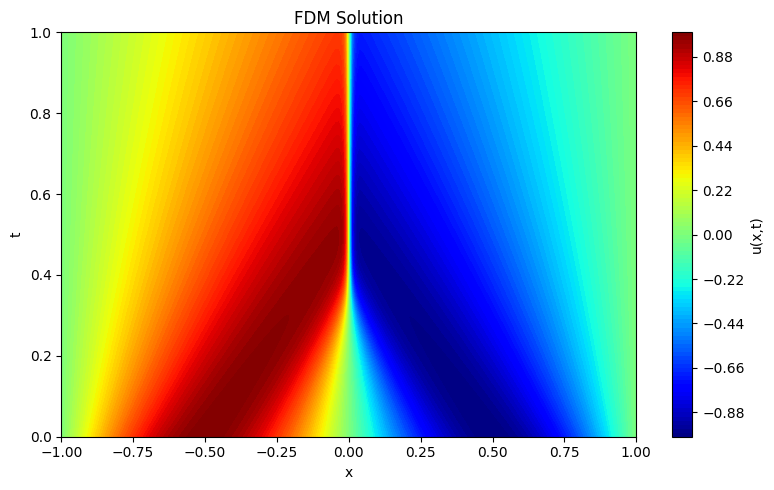

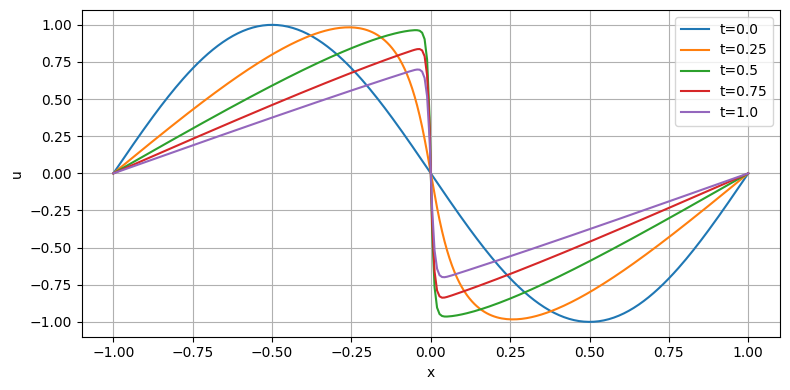

FDM runtime: 0.7931s


In [2]:
fdm = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
fdm.plot_solution()
fdm.plot_time_slices()
print(f'FDM runtime: {fdm.runtime:.4f}s')

## Section 2 - Data Conditions

In [3]:
# Clean dense
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
# Noisy sparse
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)

print('Data conditions ready')
print(f'  Clean dense  : N_ic={data_clean_dense["x_ic"].shape[0]}')
print(f'  Noisy sparse : N_ic={data_noisy_sparse["x_ic"].shape[0]}, eps=0.1')

Data conditions ready
  Clean dense  : N_ic=1000
  Noisy sparse : N_ic=20, eps=0.1


## Section 3 - Experiment 1: Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.963072 | IC: 0.302266 | BC: 0.331893 | PDE: 0.065783


Epoch  1000 | Total: 0.123450 | IC: 0.098417 | BC: 0.002461 | PDE: 0.004514


Epoch  2000 | Total: 0.054412 | IC: 0.044057 | BC: 0.000235 | PDE: 0.002024


Epoch  3000 | Total: 0.174440 | IC: 0.143128 | BC: 0.000746 | PDE: 0.006113


...

Epoch  6000 | Total: 0.013978 | IC: 0.009249 | BC: 0.000014 | PDE: 0.000943


Epoch  7000 | Total: 0.007632 | IC: 0.004701 | BC: 0.000008 | PDE: 0.000585


Epoch  8000 | Total: 0.005583 | IC: 0.003346 | BC: 0.000005 | PDE: 0.000446


Epoch  9000 | Total: 0.004413 | IC: 0.002645 | BC: 0.000004 | PDE: 0.000353



Training complete in 150.13s


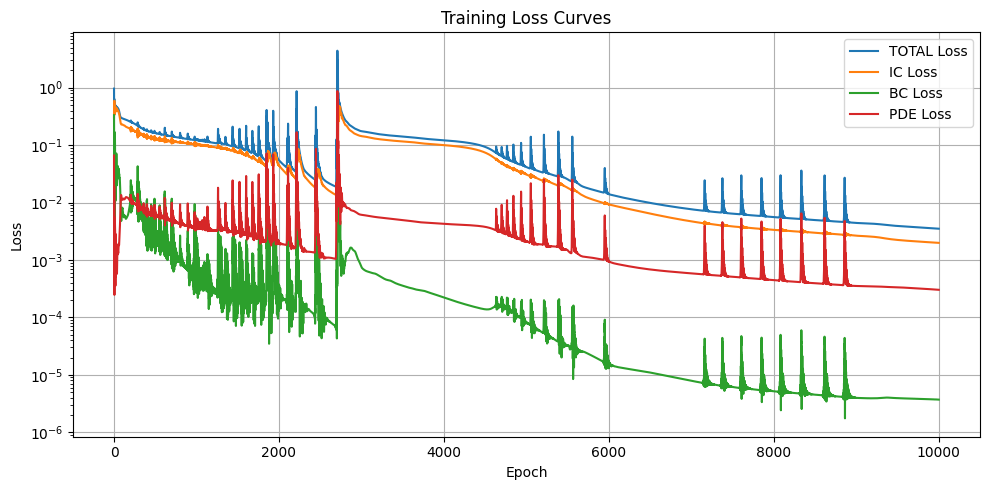

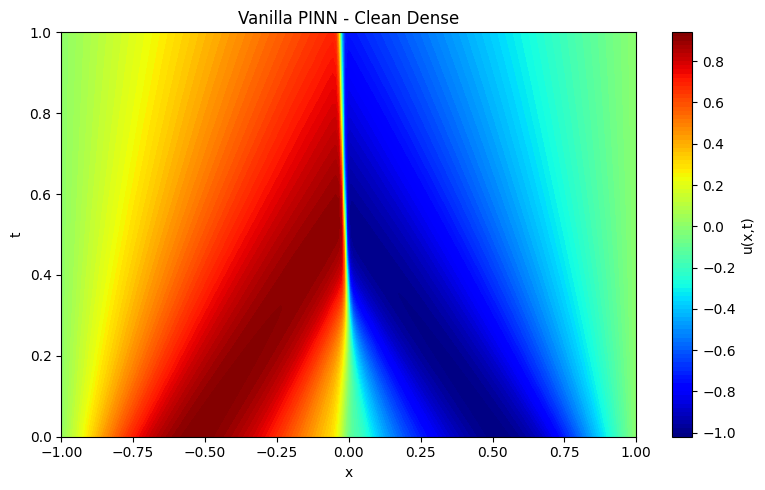

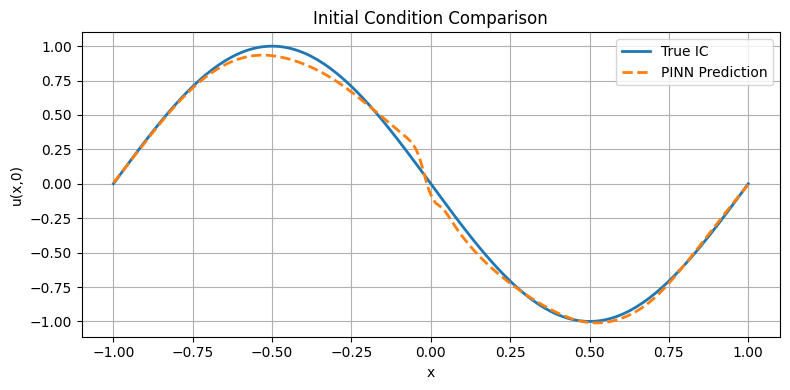

Saved: ../results/burgers/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000)
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS + 'vanilla_clean_history.npy')

## Section 4 - Experiment 2: Vanilla PINN, Noisy Sparse

Epoch     0 | Total: 0.828248 | IC: 0.358688 | BC: 0.139342 | PDE: 0.066043


Epoch  1000 | Total: 0.085230 | IC: 0.056540 | BC: 0.014517 | PDE: 0.002835


Epoch  2000 | Total: 0.055638 | IC: 0.033765 | BC: 0.013310 | PDE: 0.001713


Epoch  3000 | Total: 0.219845 | IC: 0.162399 | BC: 0.015761 | PDE: 0.008337


Epoch  4000 | Total: 0.133606 | IC: 0.098332 | BC: 0.012032 | PDE: 0.004648


...

Epoch  6000 | Total: 0.052048 | IC: 0.031677 | BC: 0.011152 | PDE: 0.001844


Epoch  7000 | Total: 0.041088 | IC: 0.023796 | BC: 0.010607 | PDE: 0.001337


Epoch  8000 | Total: 0.036534 | IC: 0.018901 | BC: 0.009958 | PDE: 0.001535


Epoch  9000 | Total: 0.029945 | IC: 0.015458 | BC: 0.009065 | PDE: 0.001085



Training complete in 132.59s


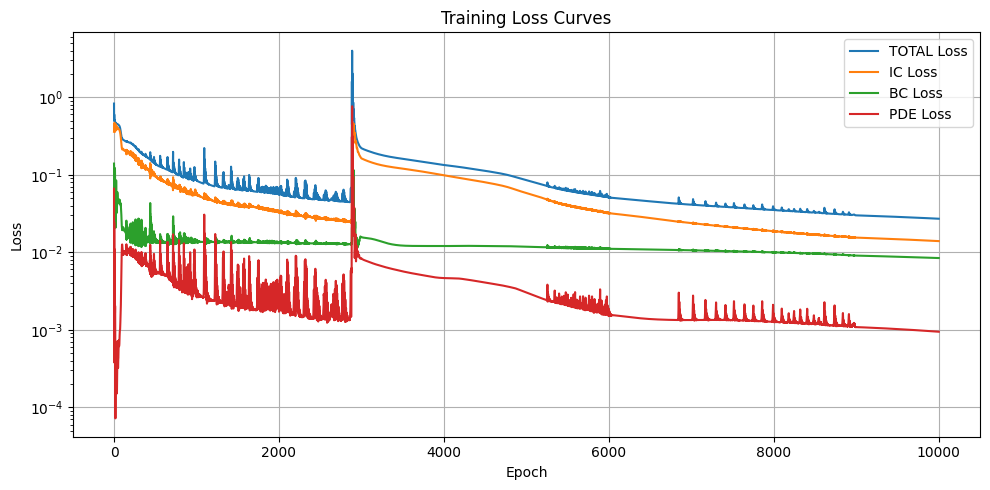

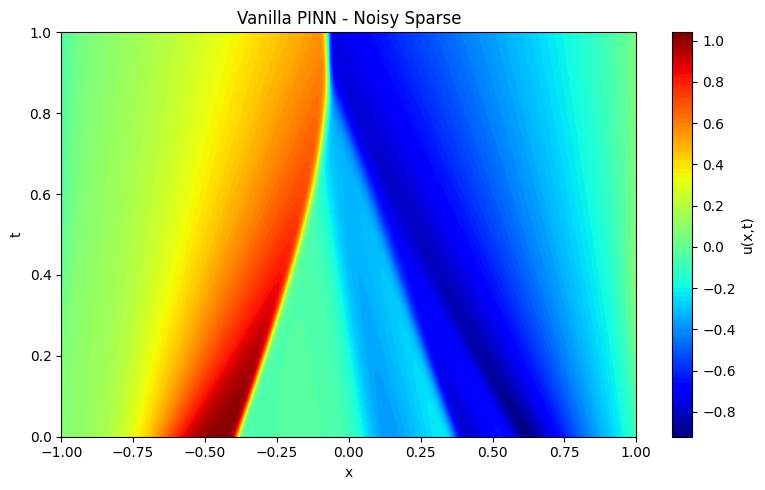

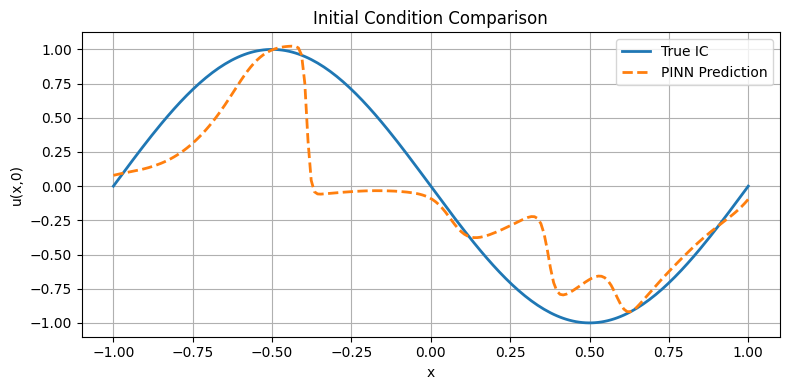

Saved: ../results/burgers/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000)
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
vanilla_noisy.plot_initial_condition_comparison(gen)
save_history(h_vn, RESULTS + 'vanilla_noisy_history.npy')

## Section 5 - Experiment 3: AC-PINN, Clean Dense

Epoch     0 | Stage 1/4 | Total: 0.683013 | IC: 0.317089 | BC: 0.284654 | PDE: 0.016254 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.009805 | IC: 0.002617 | BC: 0.000470 | PDE: 0.000198 | λ=(1.19,10.00,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.002147 | IC: 0.000176 | BC: 0.000161 | PDE: 0.000265 | λ=(5.11,1.92,3.54)


Epoch  3000 | Stage 2/4 | Total: 0.002297 | IC: 0.000024 | BC: 0.000157 | PDE: 0.000336 | λ=(10.00,1.32,5.51)


Epoch  4000 | Stage 2/4 | Total: 0.001037 | IC: 0.000010 | BC: 0.000068 | PDE: 0.000129 | λ=(10.00,1.28,6.60)


...

Epoch  6000 | Stage 3/4 | Total: 0.004651 | IC: 0.001908 | BC: 0.000225 | PDE: 0.001240 | λ=(1.70,0.20,1.10)


Epoch  7000 | Stage 3/4 | Total: 0.002116 | IC: 0.000496 | BC: 0.000094 | PDE: 0.000887 | λ=(1.01,0.19,1.80)


Epoch  8000 | Stage 4/4 | Total: 0.287970 | IC: 0.110085 | BC: 0.008161 | PDE: 0.009672 | λ=(2.58,0.19,0.23)


Epoch  9000 | Stage 4/4 | Total: 0.683402 | IC: 0.001015 | BC: 0.002732 | PDE: 0.231363 | λ=(0.10,0.10,2.95)



AC-PINN training complete in 275.78s


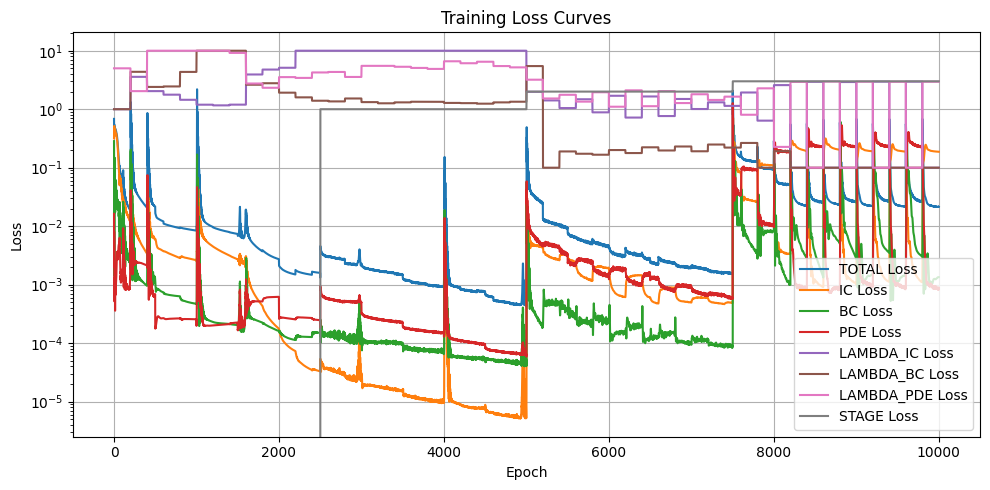

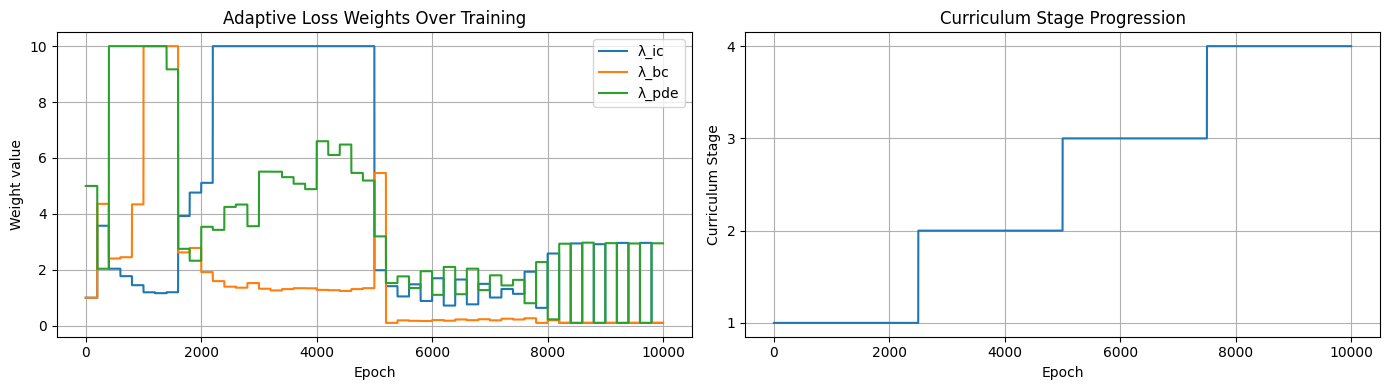

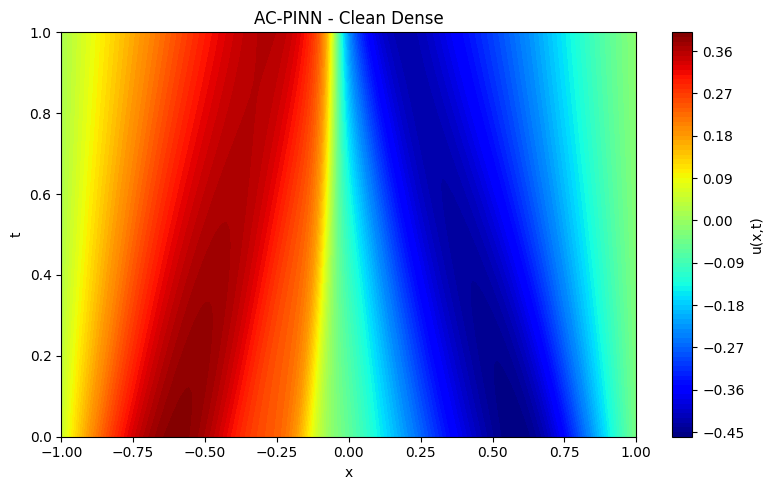

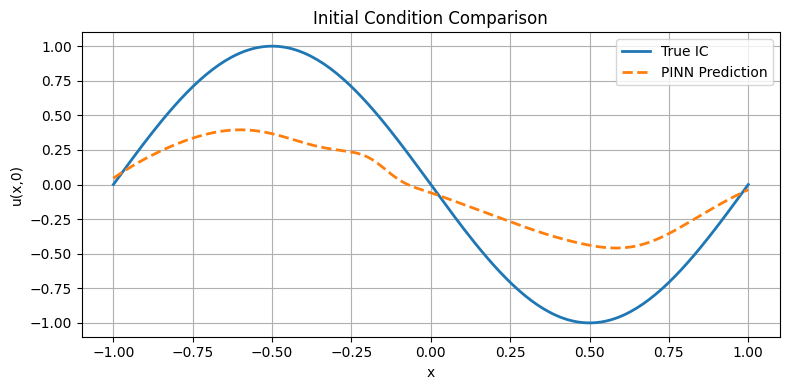

Saved: ../results/burgers/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000)
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS + 'ac_clean_history.npy')

## Section 6 - Experiment 4: AC-PINN, Noisy Sparse

Epoch     0 | Stage 1/4 | Total: 0.865446 | IC: 0.410243 | BC: 0.079303 | PDE: 0.075180 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.021764 | IC: 0.002283 | BC: 0.008278 | PDE: 0.000015 | λ=(4.52,1.37,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.014842 | IC: 0.001303 | BC: 0.007201 | PDE: 0.000003 | λ=(3.59,1.41,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.017078 | IC: 0.001347 | BC: 0.007078 | PDE: 0.000021 | λ=(2.17,1.97,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.012170 | IC: 0.001094 | BC: 0.004682 | PDE: 0.000003 | λ=(2.12,2.10,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.018654 | IC: 0.002478 | BC: 0.008128 | PDE: 0.001262 | λ=(0.63,2.05,0.32)


Epoch  7000 | Stage 3/4 | Total: 0.017698 | IC: 0.001564 | BC: 0.007606 | PDE: 0.001370 | λ=(0.45,2.17,0.39)


Epoch  8000 | Stage 4/4 | Total: 0.125595 | IC: 0.036780 | BC: 0.014190 | PDE: 0.052837 | λ=(1.06,0.41,1.53)


Epoch  9000 | Stage 4/4 | Total: 0.394538 | IC: 0.145200 | BC: 0.015584 | PDE: 0.001434 | λ=(2.69,0.29,0.10)



AC-PINN training complete in 371.80s


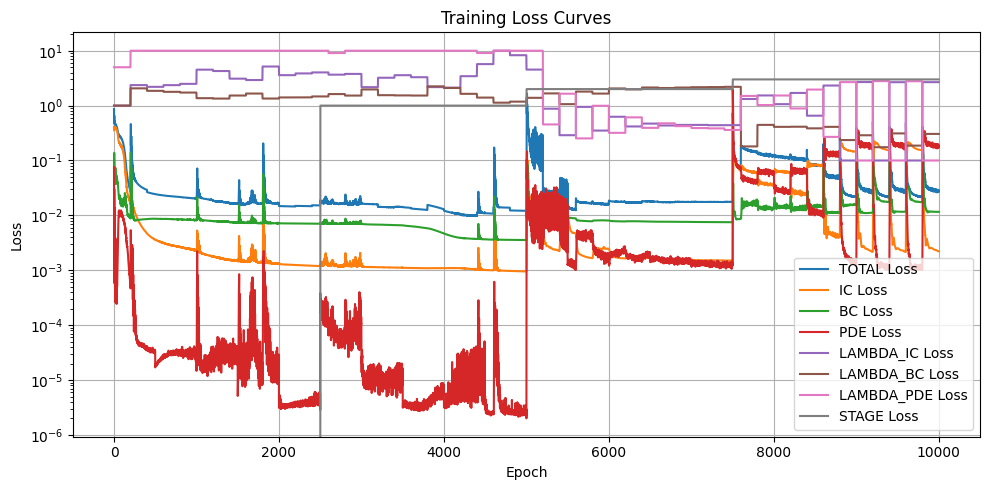

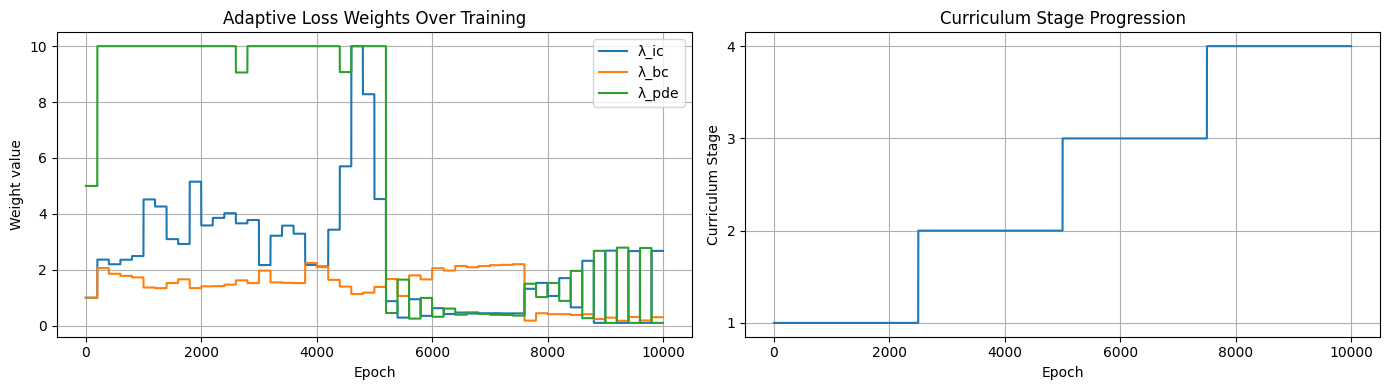

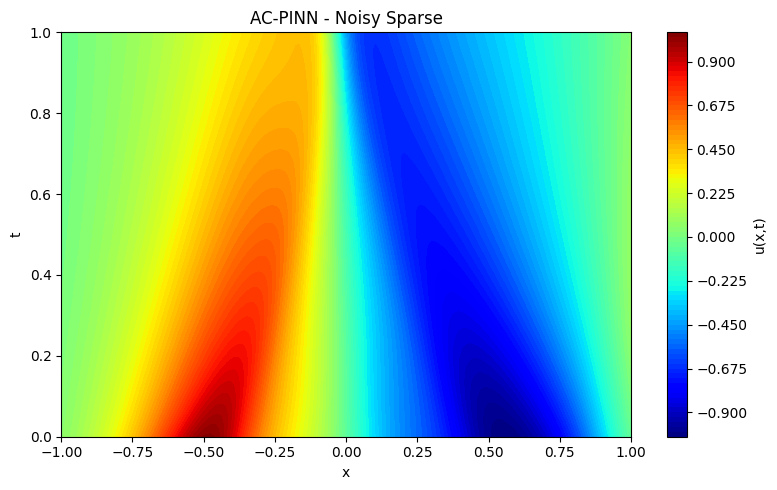

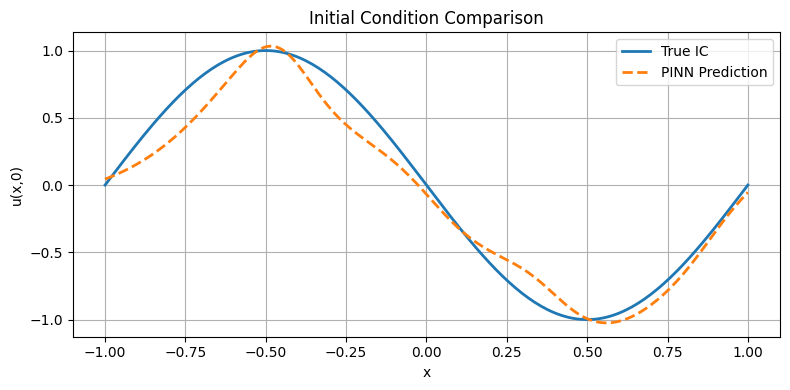

Saved: ../results/burgers/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000)
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
ac_noisy.plot_initial_condition_comparison(gen)
save_history(h_an, RESULTS + 'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.174012   1.416779   0.025795   0.105828
  Vanilla (noisy)             0.538481   1.504175   0.183198   0.327485
  AC-PINN (clean)             0.608142   1.016729   0.280975   0.369851
  AC-PINN (noisy)             0.379828   0.966123   0.150614   0.230998


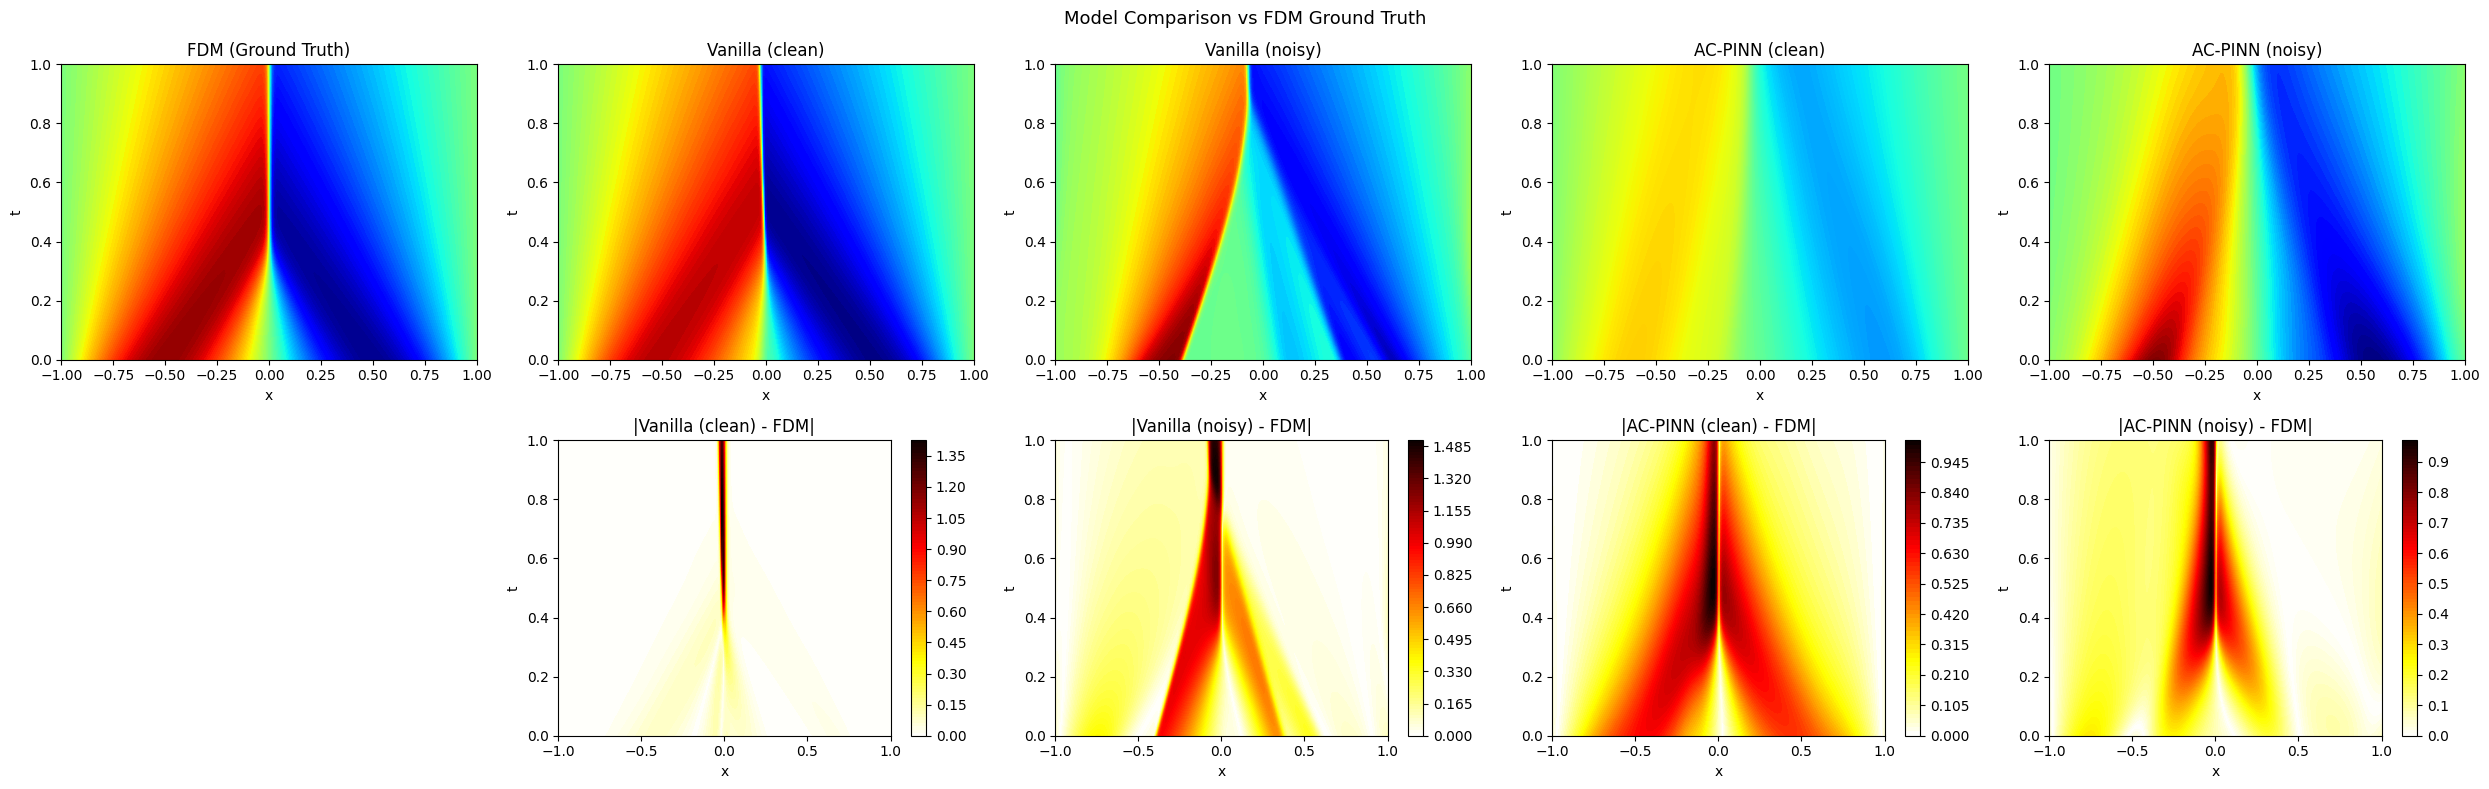

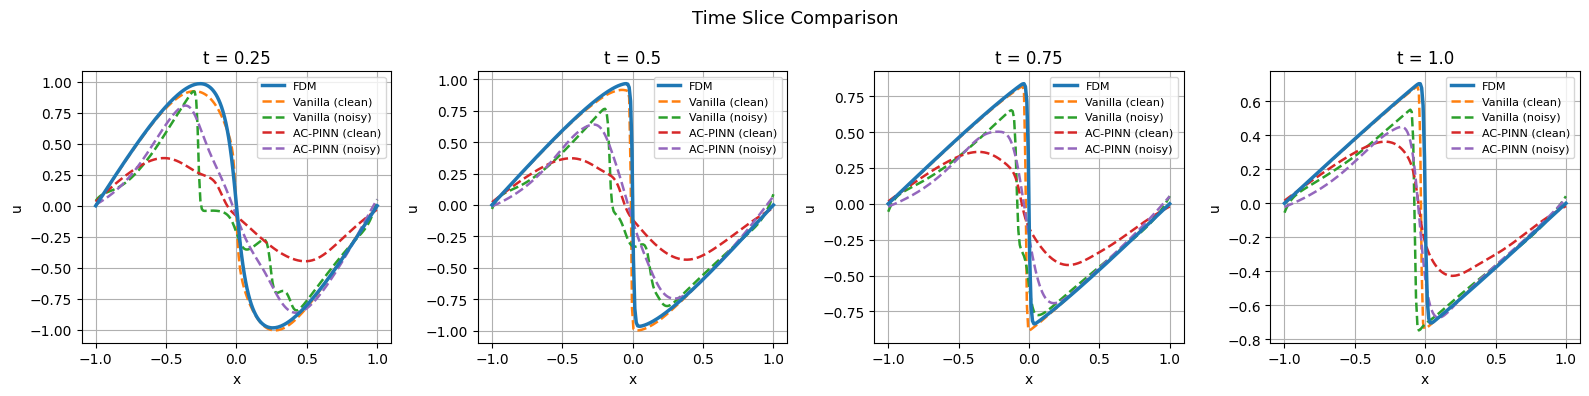

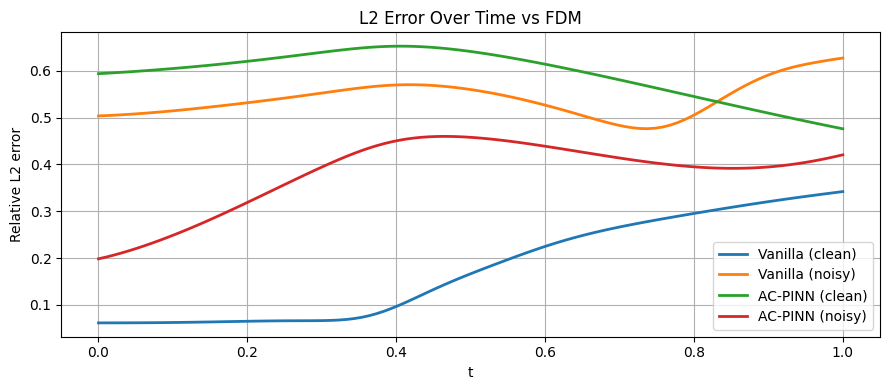

Saved: ../results/burgers/benchmark_metrics.npy
Burgers experiments complete. Results saved.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)',  vanilla_clean)
bench.add('Vanilla (noisy)',  vanilla_noisy)
bench.add('AC-PINN (clean)',  ac_clean)
bench.add('AC-PINN (noisy)',  ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Burgers experiments complete. Results saved.')

## Section 8 - Noise Level Study (ε = 0.05, 0.1, 0.2)
AC-PINN vs Vanilla under increasing noise.

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- Noise level ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)

    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)

    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)

    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()

save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Noise study complete.')


--- Noise level ε=0.05 ---
Epoch     0 | Total: 0.651661 | IC: 0.589857 | BC: 0.058066 | PDE: 0.000747


Epoch  2500 | Total: 0.062192 | IC: 0.046673 | BC: 0.004202 | PDE: 0.002263



Training complete in 178.63s
Epoch     0 | Stage 1/4 | Total: 0.619863 | IC: 0.578037 | BC: 0.041681 | PDE: 0.000029 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.016402 | IC: 0.001732 | BC: 0.004049 | PDE: 0.000207 | λ=(5.09,1.56,6.22)



AC-PINN training complete in 178.62s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.326550   1.582920   0.082950   0.198596
  AC-PINN ε=0.05              0.291174   0.866556   0.097533   0.177082

--- Noise level ε=0.1 ---
Epoch     0 | Total: 1.215629 | IC: 0.772124 | BC: 0.274434 | PDE: 0.033814


...


AC-PINN training complete in 174.55s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.625082   2.103449   0.154493   0.380153
  AC-PINN ε=0.1               0.266568   1.144636   0.099360   0.162117

--- Noise level ε=0.2 ---
Epoch     0 | Total: 0.805184 | IC: 0.472297 | BC: 0.115295 | PDE: 0.043518


Epoch  2500 | Total: 0.134479 | IC: 0.074504 | BC: 0.050438 | PDE: 0.001907



Training complete in 155.26s
Epoch     0 | Stage 1/4 | Total: 0.952708 | IC: 0.761794 | BC: 0.173681 | PDE: 0.003447 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.172354 | IC: 0.020103 | BC: 0.040224 | PDE: 0.000049 | λ=(5.21,1.67,4.75)



AC-PINN training complete in 168.02s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.466721   0.972372   0.159343   0.283843
  AC-PINN ε=0.2               0.320101   0.838552   0.123049   0.194674
Saved: ../results/burgers/noise_study_metrics.npy
Noise study complete.
